# Random Forest Gunshot Classifier — Training & Evaluation

This notebook loads the feature CSV and:
1. Creates a **balanced test set**
2. Trains a **Random Forest** classifier on the remaining data
3. Reports comprehensive evaluation metrics
4. Plots **Learning Curves** to diagnose overfitting/underfitting
5. Runs **Cross-Validation** for robust scoring
6. Saves a **Predictions CSV** with actual vs predicted labels

In [1]:
%pip install -q scikit-learn pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score,
    classification_report, confusion_matrix,
    log_loss, r2_score, roc_auc_score, roc_curve, matthews_corrcoef,
    precision_recall_curve,

)

SEED = 42
np.random.seed(SEED)
print(' All imports loaded.')

 All imports loaded.


## Step 1: Load Dataset

In [4]:
def resolve_data_root():
    current = Path.cwd().resolve()
    expected_subdirs = ('edge-collected-gunshot-audio', 'gun', 'audio', 'sound')
    best_data_dir = None
    best_score = -1
    best_depth = 10**9

    for candidate in [current, *current.parents]:
        data_dir = candidate / 'Data'
        if not data_dir.exists():
            continue
        score = sum((data_dir / subdir).exists() for subdir in expected_subdirs)
        depth = len(data_dir.parts)
        if score > best_score or (score == best_score and depth < best_depth):
            best_data_dir = data_dir
            best_score = score
            best_depth = depth

    if best_data_dir is None:
        raise FileNotFoundError("Could not locate a valid Data folder.")

    return best_data_dir, best_score

BASE_DIR, DATA_MATCH_SCORE = resolve_data_root()
PROJECT_ROOT = BASE_DIR.parent
OUTPUT_DIR = BASE_DIR / 'Output'
CSV_PATH = OUTPUT_DIR / 'dataset_features.csv'

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Balanced dataset CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
print(f' Project root             : {PROJECT_ROOT}')
print(f' Data root                : {BASE_DIR} (match score: {DATA_MATCH_SCORE}/4)')
print(f' Dataset loaded           : {len(df)} samples')
print(f'   Class 0 (non-gunshot)  : {(df["label"] == 0).sum()}')
print(f'   Class 1 (gunshot)      : {(df["label"] == 1).sum()}')
print(f'   Features               : {len([c for c in df.columns if c.startswith("mfcc_")])}')
print(f'   CSV path               : {CSV_PATH}')
df.head()

 Project root             : C:\Desktop\Data-Cleaner
 Data root                : C:\Desktop\Data-Cleaner\Data (match score: 4/4)
 Dataset loaded           : 10368 samples
   Class 0 (non-gunshot)  : 6230
   Class 1 (gunshot)      : 4138
   Features               : 80
   CSV path               : C:\Desktop\Data-Cleaner\Data\Output\dataset_features.csv


,file_path,trimmed_duration_ms,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,...,mfcc_70,mfcc_71,mfcc_72,mfcc_73,mfcc_74,mfcc_75,mfcc_76,mfcc_77,mfcc_78,mfcc_79
0,C:\Desktop\Data-Cleaner\Data\audio\16000\4-181...,5000.00,0,-584.86615,67.272750,-5.909483,16.873217,8.442039,14.823366,6.674617,...,3.218015,4.608699,4.050599,3.394491,3.145775,5.859838,4.350021,4.878862,2.999315,4.219984
1,C:\Desktop\Data-Cleaner\Data\audio\1-67432-A-2...,5000.00,0,-156.12706,-30.381441,-2.520434,10.042791,19.838245,10.902749,-0.367382,...,3.059962,3.383876,3.242513,3.057203,3.687129,3.045339,3.391944,2.762360,2.966041,3.237614
2,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,7407.17,1,-580.84960,120.700745,-5.382522,32.750850,4.447424,11.394693,4.349498,...,4.130706,3.603147,3.279809,3.347042,3.039511,3.718764,2.967764,3.088598,2.866388,2.802322
3,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1578.96,1,-576.44670,17.956106,-11.108670,2.149039,-12.501011,-0.905995,-5.445512,...,2.838675,2.634249,2.655603,3.036999,2.199270,1.886445,2.920240,1.517998,1.687609,2.067152
4,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,789.48,1,-630.71277,30.392002,-2.860079,1.925278,2.473357,1.391537,3.274570,...,1.542560,1.328898,2.045226,1.503679,1.630705,1.548071,1.902350,1.629477,1.458646,1.132491


## Step 2: Balanced x/x Train-Test Split

In [5]:
TARGET_TEST_PER_CLASS = 4000

df_0 = df[df['label'] == 0].copy()
df_1 = df[df['label'] == 1].copy()

available_per_class = min(len(df_0), len(df_1))
if available_per_class <= 1:
    raise ValueError(
        f"Not enough samples per class for train/test split. "
        f"Class0={len(df_0)}, Class1={len(df_1)}"
    )

# Keep at least one sample per class for training.
TEST_PER_CLASS = min(TARGET_TEST_PER_CLASS, available_per_class - 1)

test_0 = df_0.sample(n=TEST_PER_CLASS, random_state=SEED)
test_1 = df_1.sample(n=TEST_PER_CLASS, random_state=SEED)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=SEED)

train_df = df.drop(test_df.index).sample(frac=1, random_state=SEED)

feature_cols = [c for c in df.columns if c.startswith('mfcc_')]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['label'].values

print(f' Target test per class: {TARGET_TEST_PER_CLASS}')
print(f' Using test per class : {TEST_PER_CLASS}')
print(f' Train set: {len(train_df)} samples  '
      f'(Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()})')
print(f' Test  set: {len(test_df)} samples  '
      f'(Class 0: {(y_test==0).sum()}, Class 1: {(y_test==1).sum()})')

 Target test per class: 4000
 Using test per class : 4000
 Train set: 2368 samples  (Class 0: 2230, Class 1: 138)
 Test  set: 8000 samples  (Class 0: 4000, Class 1: 4000)


## Step 3: Feature Scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(' Features scaled with StandardScaler.')

 Features scaled with StandardScaler.


## Step 4: Train Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)

print(' Training Random Forest ...')
rf.fit(X_train_scaled, y_train)
print(' Random Forest training complete!')
print(f'   Number of trees  : {rf.n_estimators}')
print(f'   Max depth        : {rf.max_depth}')
print(f'   Features used    : {rf.n_features_in_}')

 Training Random Forest ...
 Random Forest training complete!
   Number of trees  : 200
   Max depth        : None
   Features used    : 80


## Step 5:  Evaluation Metrics

In [8]:
y_proba = rf.predict_proba(X_test_scaled)
y_score = y_proba[:, 1]

# Tune threshold using out-of-fold training probabilities only (no test leakage).
cv_for_threshold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_train_proba = cross_val_predict(
    rf, X_train_scaled, y_train, cv=cv_for_threshold, method='predict_proba', n_jobs=1
)[:, 1]

prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_train, oof_train_proba)
f1_curve = (2 * prec_curve[:-1] * rec_curve[:-1]) / (prec_curve[:-1] + rec_curve[:-1] + 1e-12)

if len(pr_thresholds) == 0:
    best_threshold = 0.50
else:
    best_threshold = float(pr_thresholds[np.nanargmax(f1_curve)])

y_pred_default = (y_score >= 0.50).astype(int)
y_pred = (y_score >= best_threshold).astype(int)

acc      = accuracy_score(y_test, y_pred)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
bal_acc  = balanced_accuracy_score(y_test, y_pred)
logloss  = log_loss(y_test, y_proba)
r2       = r2_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_score)
mcc      = matthews_corrcoef(y_test, y_pred)

baseline_prec = precision_score(y_test, y_pred_default)
baseline_rec  = recall_score(y_test, y_pred_default)
baseline_f1   = f1_score(y_test, y_pred_default)

metrics_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score',
        'Log Loss', 'R² Score', 'ROC-AUC', 'Matthews Corr. Coeff.'
    ],
    'Score': [acc, bal_acc, prec, rec, f1, logloss, r2, roc_auc, mcc]
})
metrics_df['Score'] = metrics_df['Score'].round(4)

print('\n Threshold tuning (from train CV only):')
print(f'   Best threshold (F1-optimal): {best_threshold:.4f}')
print(f'   Baseline @0.50 -> Precision: {baseline_prec:.4f}, Recall: {baseline_rec:.4f}, F1: {baseline_f1:.4f}')
print(f'   Tuned threshold -> Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}')

print('\n' + '='*50)
print('      RANDOM FOREST EVALUATION METRICS')
print('='*50)
for _, row in metrics_df.iterrows():
    icon = 'yes' if row['Metric'] not in ['Log Loss'] or row['Score'] < 0.5 else 'no'
    print(f'  {icon} {row["Metric"]:<25} {row["Score"]:>10.4f}')
print('='*50)
metrics_df


 Threshold tuning (from train CV only):
   Best threshold (F1-optimal): 0.3310
   Baseline @0.50 -> Precision: 0.9936, Recall: 0.6973, F1: 0.8195
   Tuned threshold -> Precision: 0.9896, Recall: 0.8327, F1: 0.9044

      RANDOM FOREST EVALUATION METRICS
  yes Accuracy                      0.9120
  yes Balanced Accuracy             0.9120
  yes Precision                     0.9896
  yes Recall                        0.8328
  yes F1 Score                      0.9044
  yes Log Loss                      0.2763
  yes R² Score                      0.6480
  yes ROC-AUC                       0.9944
  yes Matthews Corr. Coeff.         0.8345


,Metric,Score
0,Accuracy,0.9120
1,Balanced Accuracy,0.9120
2,Precision,0.9896
3,Recall,0.8328
4,F1 Score,0.9044
5,Log Loss,0.2763
6,R² Score,0.6480
7,ROC-AUC,0.9944
8,Matthews Corr. Coeff.,0.8345


In [9]:
print('\n Classification Report:\n')
print(classification_report(
    y_test, y_pred,
    target_names=['Non-Gunshot (0)', 'Gunshot (1)']
))


 Classification Report:

                 precision    recall  f1-score   support

Non-Gunshot (0)       0.86      0.99      0.92      4000
    Gunshot (1)       0.99      0.83      0.90      4000

       accuracy                           0.91      8000
      macro avg       0.92      0.91      0.91      8000
   weighted avg       0.92      0.91      0.91      8000



## Step 6:  Confusion Matrix

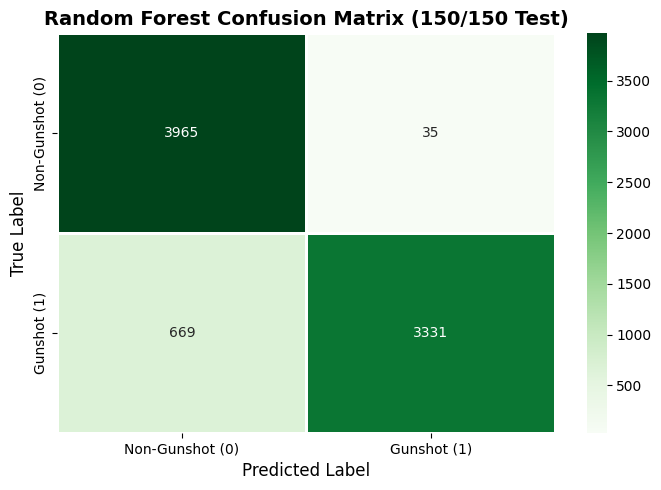

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Gunshot (0)', 'Gunshot (1)'],
            yticklabels=['Non-Gunshot (0)', 'Gunshot (1)'],
            linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Random Forest Confusion Matrix (150/150 Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7:  ROC Curve

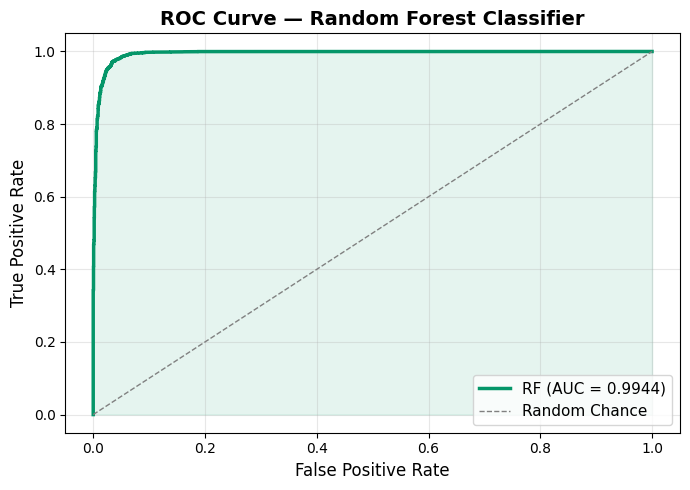

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#059669', lw=2.5, label=f'RF (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Chance')
ax.fill_between(fpr, tpr, alpha=0.1, color='#059669')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Random Forest Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8:  Learning Curves (Overfitting / Underfitting Diagnostic)



 Computing learning curves (this may take a minute) ...


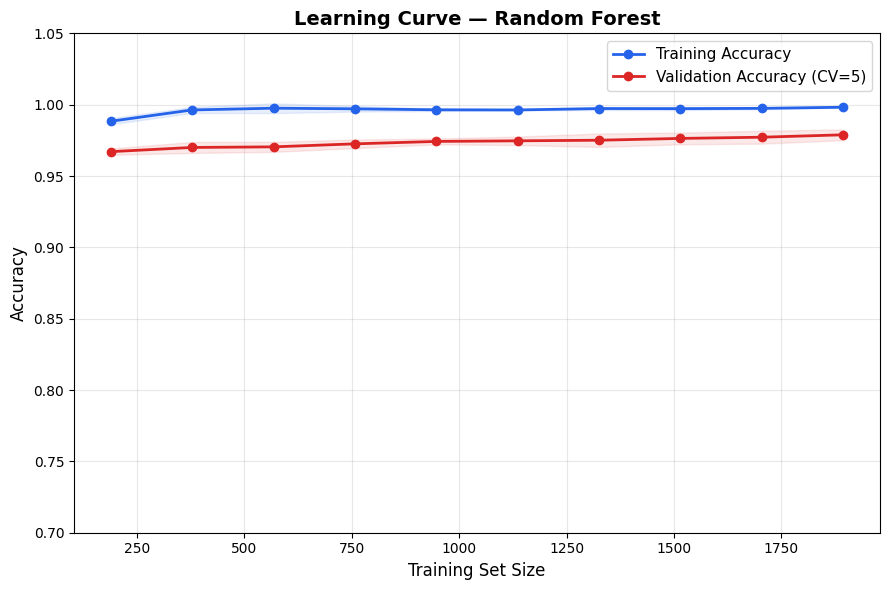


 Final gap (train - val): 0.0193
 Model appears well-fitted!


In [12]:
print(' Computing learning curves (this may take a minute) ...')

train_sizes, train_scores, val_scores = learning_curve(
    rf, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    random_state=SEED
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#2563eb', lw=2, label='Training Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2563eb')
ax.plot(train_sizes, val_mean, 'o-', color='#dc2626', lw=2, label='Validation Accuracy (CV=5)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#dc2626')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Learning Curve — Random Forest', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'\n Final gap (train - val): {gap:.4f}')
if gap > 0.05:
    print('  Potential OVERFITTING detected (gap > 5%)')
elif val_mean[-1] < 0.85:
    print('  Potential UNDERFITTING detected (val accuracy < 85%)')
else:
    print(' Model appears well-fitted!')

## Step 9:  Cross-Validation Scores

In [13]:
print(' Running 5-fold Stratified Cross-Validation ...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=1)

print(f'\n Cross-Validation Results (5-Fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i}: {score:.4f}')
print(f'\n   Mean Accuracy : {cv_scores.mean():.4f}')
print(f'   Std Deviation : {cv_scores.std():.4f}')

cv_f1 = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=1)
print(f'\n   Mean F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

 Running 5-fold Stratified Cross-Validation ...

 Cross-Validation Results (5-Fold):
   Fold 1: 0.9789
   Fold 2: 0.9726
   Fold 3: 0.9852
   Fold 4: 0.9810
   Fold 5: 0.9810

   Mean Accuracy : 0.9797
   Std Deviation : 0.0041

   Mean F1 Score : 0.7961 ± 0.0426


## Step 10:  Save Test Predictions CSV

Saves a CSV with `file_path`, `actual_label`, `predicted_label`, `predicted_proba_gunshot` for the test set.

In [14]:
predictions_df = test_df[['file_path', 'label']].copy()
predictions_df = predictions_df.rename(columns={'label': 'actual_label'})
predictions_df['predicted_label'] = y_pred
predictions_df['predicted_label_0_50'] = y_pred_default
predictions_df['decision_threshold'] = round(best_threshold, 4)
predictions_df['predicted_proba_gunshot'] = y_score.round(4)
predictions_df['correct'] = (predictions_df['actual_label'] == predictions_df['predicted_label'])
predictions_df['correct_0_50'] = (predictions_df['actual_label'] == predictions_df['predicted_label_0_50'])

pred_csv_path = OUTPUT_DIR / 'rf_test_predictions.csv'
predictions_df.to_csv(pred_csv_path, index=False)

n_correct = predictions_df['correct'].sum()
n_wrong   = (~predictions_df['correct']).sum()
n_correct_050 = predictions_df['correct_0_50'].sum()
n_wrong_050   = (~predictions_df['correct_0_50']).sum()

print(f' Predictions saved to: {pred_csv_path}')
print(f'   Threshold used      : {best_threshold:.4f}')
print(f'   Tuned correct       : {n_correct} / {len(predictions_df)}')
print(f'   Tuned incorrect     : {n_wrong} / {len(predictions_df)}')
print(f'   Baseline 0.50 right : {n_correct_050} / {len(predictions_df)}')
print(f'   Baseline 0.50 wrong : {n_wrong_050} / {len(predictions_df)}')

print(f'\n Misclassified samples with tuned threshold:')
misclassified = predictions_df[~predictions_df['correct']]
if len(misclassified) == 0:
    print('   None! Perfect predictions on test set.')
else:
    display(misclassified)

 Predictions saved to: C:\Desktop\Data-Cleaner\Data\Output\rf_test_predictions.csv
   Threshold used      : 0.3310
   Tuned correct       : 7296 / 8000
   Tuned incorrect     : 704 / 8000
   Baseline 0.50 right : 6771 / 8000
   Baseline 0.50 wrong : 1229 / 8000

 Misclassified samples with tuned threshold:


,file_path,actual_label,predicted_label,predicted_label_0_50,decision_threshold,predicted_proba_gunshot,correct,correct_0_50
1019,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.2960,False,False
2705,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.2731,False,False
5813,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.1892,False,False
8446,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.1998,False,False
8620,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.2175,False,False
...,...,...,...,...,...,...,...,...
6761,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.0927,False,False
604,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.2872,False,False
4955,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.1673,False,False
6506,C:\Desktop\Data-Cleaner\Data\Output\trimmed_gu...,1,0,0,0.331,0.3110,False,False


## Step 11:  Metrics Bar Chart

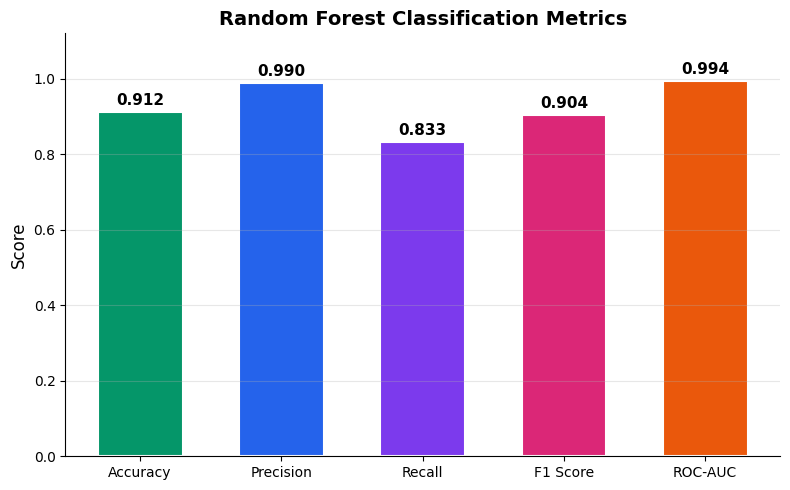

In [15]:
plot_metrics = metrics_df[metrics_df['Metric'].isin(
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
)].copy()

colors = ['#059669', '#2563eb', '#7c3aed', '#db2777', '#ea580c']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_metrics['Metric'], plot_metrics['Score'],
              color=colors, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, plot_metrics['Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest Classification Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()